# CSED 504 — A1 Computer Vision: Training CIFAR-10 (the standard way)

In the *hello_image* notebook we built a Vision Transformer **by hand** — patch embedding,
attention blocks, the forward pass, all spelled out. That is the right way to *learn* what a
model is doing. But it is not how you actually train an image classifier day-to-day.

This notebook shows the **standard, idiomatic PyTorch workflow** for CIFAR-10. Instead of
writing every layer ourselves, we lean on the batteries-included pieces the ecosystem gives us:

| Job | Hand-rolled version | Standard tool |
|-----|--------------------|---------------|
| Get the data | write our own loader / synthetic tensors | `torchvision.datasets.CIFAR10` |
| Preprocess & augment | manual crops/normalize | `torchvision.transforms` |
| Batch & shuffle | manual index slicing | `torch.utils.data.DataLoader` |
| The model | define every layer | `torchvision.models.resnet18` |
| Loss | write cross-entropy | `nn.CrossEntropyLoss` |
| Update rule | write SGD by hand | `torch.optim.SGD` + a scheduler |
| Speed | fp32 everywhere | `torch.amp` mixed precision |

The pattern below — **transforms → dataset → loader → model → loss/optimizer → epoch loop of
train + evaluate** — is the same skeleton you'll reuse for almost any supervised vision task.
Swap the dataset and the model and everything else stays put.

---
**To use in Google Colab:**
```
!git clone https://github.com/TrueRottweiler/WashingtonCsed504.git
%cd WashingtonCsed504/src/a1-cv
```
Then set **Runtime → Change runtime type → GPU** and run all cells.

In [1]:
# Install required packages.  If you're running in the uw-csed504 conda environment these
# are already installed and this is a no-op.  For Colab or fresh setups it will pull them in.
%pip install --quiet torch torchvision numpy matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
# -- 1. Path setup + device detection --------------------------------------------------------------
# Same pattern as hello_image.ipynb: add the shared common/ folder to the import path so we can
# reuse gpu_check.py (device detection + reproducible seeds).  os.getcwd() is normally this
# notebook's folder (src/a1-cv/), so '../common' resolves to src/common/.

import os, sys

_common = os.path.normpath(os.path.join(os.getcwd(), '../common'))
if os.path.isdir(_common) and _common not in sys.path:
    sys.path.insert(0, _common)

try:
    from gpu_check import get_device, set_seed
    DEVICE = get_device()          # detects CUDA -> MPS -> CPU and prints what it found
    set_seed(42)                   # lock Python/NumPy/torch RNGs for reproducibility
    # Optional single-GPU speedup on NVIDIA (TF32 + cuDNN autotune).  Safe no-op elsewhere.
    try:
        from gpu_check import enable_fast_matmul
        enable_fast_matmul()
    except Exception:
        pass
except ImportError:
    # Fallback inline detection — runs if common/ isn't reachable (e.g. odd Colab layout)
    import random, numpy as np, torch
    if torch.cuda.is_available():
        DEVICE = torch.device('cuda')
        print(f'  Device   : CUDA — {torch.cuda.get_device_name(0)}')
    elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
        DEVICE = torch.device('mps'); print('  Device   : MPS — Apple Silicon GPU')
    else:
        DEVICE = torch.device('cpu'); print(f'  Device   : CPU ({os.cpu_count() or 1} cores)')
    random.seed(42); np.random.seed(42); torch.manual_seed(42)

  PyTorch  : 2.11.0+cu128
  CUDA     : 12.8
  Device   : cuda  [2 GPUs visible - CUDA_VISIBLE_DEVICES='GPU-b09775ec-7817-5003-b4ac-cc406fac5a51,GPU-5b633072-72ed-f715-70ab-c3b32cba0178']
    cuda:0  NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition  sm_120  102.6 GB  <- cuda:0 (primary)
    cuda:1  NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition  sm_120  102.6 GB
  Multi-GPU (2 cards) - pick by goal:
    - FASTER inner loop: stay on ONE card + enable_fast_matmul() + bf16 autocast. DataParallel rarely helps at class model scale
      (comms overhead cancels the 2nd card); measure before relying on it.
    - MORE experiments at once: launch a separate run per card
    - BIGGER model (won't fit on 1 card): device_map="auto", max_memory=get_max_memory()


In [3]:
import time
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

print('torchvision', torchvision.__version__)

torchvision 0.26.0+cu128


## 1. Data — `transforms`, `datasets`, and `DataLoader`

Three standard objects do all the data work:

- **`transforms`** — a pipeline applied to each image. For **training** we add light *data
  augmentation* (random crop with padding + horizontal flip) so the model sees slightly different
  versions of each image every epoch and generalizes better. For **testing** we do *not* augment —
  we want a fixed, honest measurement. Both pipelines end by converting to a tensor and
  **normalizing** with CIFAR-10's per-channel mean/std, which centers the inputs and helps the
  optimizer.
- **`datasets.CIFAR10`** — downloads the 60,000 32×32 images (50k train / 10k test) the first time
  and caches them under `./data`. It applies the transform we hand it.
- **`DataLoader`** — wraps a dataset and hands us shuffled **batches**, optionally using worker
  processes to load in parallel. This replaces any manual index-slicing.

In [4]:
# CIFAR-10 per-channel mean and standard deviation (computed over the training set).  These
# are the standard published values everyone uses; normalizing to them centers each color channel.
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# Training pipeline: augment, then tensor-ify and normalize.
#   RandomCrop(32, padding=4)  — pad 4px on each side, crop a random 32x32 window -> small shifts
#   RandomHorizontalFlip()     — mirror left<->right 50% of the time (a flipped cat is still a cat)
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),                       # PIL image -> float tensor in [0,1], shape (C,H,W)
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Test pipeline: NO augmentation — just the deterministic tensor + normalize.
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Datasets: download=True fetches CIFAR-10 into ./data on first run, then reuses the cache.
train_set = datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_tf)
test_set  = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)

CLASSES = train_set.classes   # ['airplane', 'automobile', 'bird', ... ] — 10 names
print(f'Train images: {len(train_set):,}   Test images: {len(test_set):,}')
print(f'Classes ({len(CLASSES)}): {CLASSES}')

c:\Users\truer\.conda\envs\uw-csed504\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train images: 50,000   Test images: 10,000
Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [5]:
# DataLoaders turn the datasets into iterators over shuffled batches.
#
# BATCH_SIZE  — images per gradient step.  128 is a common CIFAR default; lower it if you hit
#               out-of-memory on a small GPU.
# NUM_WORKERS — background processes that prefetch/decode data so the GPU never waits on I/O.
#               On Windows notebooks worker subprocesses can hang (spawn start-method quirk), so
#               we default to 0 there and 2 elsewhere.  Bump it up on Linux/Mac for more speed.
# pin_memory  — pinned host memory copies to the GPU faster; only useful on CUDA.
BATCH_SIZE  = 128
NUM_WORKERS = 0 if os.name == 'nt' else 2
PIN         = (DEVICE.type == 'cuda')

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN)
test_loader  = DataLoader(test_set,  batch_size=256,        shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN)

# Peek at one batch to confirm shapes: images are (B, 3, 32, 32), labels are (B,) integer classes.
images, labels = next(iter(train_loader))
print(f'One batch -> images {tuple(images.shape)}, labels {tuple(labels.shape)}')

One batch -> images (128, 3, 32, 32), labels (128,)


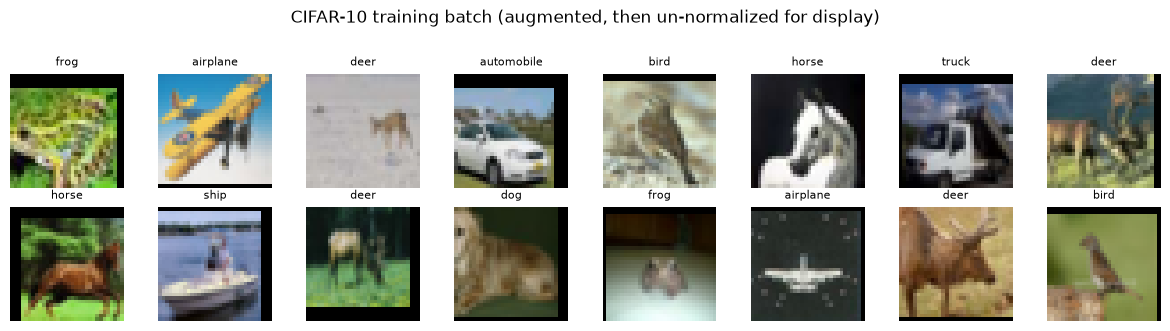

In [6]:
# -- Visualize a batch -----------------------------------------------------------------------------
# The images are normalized (values roughly centered on 0), so to view them we UN-normalize:
# multiply by std and add the mean to get back into [0,1], then move channels last for matplotlib.
def denormalize(img):
    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    std  = torch.tensor(CIFAR_STD).view(3, 1, 1)
    return (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(images[i]))
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('CIFAR-10 training batch (augmented, then un-normalized for display)', y=1.02)
plt.tight_layout()
plt.show()

## 2. Model — a prebuilt `ResNet-18`, lightly adapted for 32×32

Rather than defining every layer, we grab **ResNet-18** from `torchvision.models`. ResNet
(*Deep Residual Learning*, He et al. 2015) is the workhorse CNN: stacks of convolutions with
**residual (skip) connections** that let gradients flow through very deep networks.

One catch: torchvision's ResNet is built for **224×224 ImageNet** images. Its stem starts with a
7×7 stride-2 convolution and a max-pool, which together downsample 4× immediately — far too
aggressive for a 32×32 image, which would be crushed to 8×8 before any real work happens. The
standard **CIFAR adaptation** is to replace that stem with a gentle 3×3 stride-1 convolution and
drop the initial max-pool, and to size the final layer to 10 classes. This is a well-known recipe,
not something we're inventing.

In [7]:
def make_cifar_resnet18(num_classes=10):
    """torchvision ResNet-18 with an ImageNet stem swapped for a CIFAR-friendly one."""
    # weights=None -> random initialization (training from scratch, as chosen).
    model = models.resnet18(weights=None, num_classes=num_classes)

    # Replace the 7x7 stride-2 stem conv with a 3x3 stride-1 conv (keeps 32x32 resolution).
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

    # Remove the early max-pool (it would downsample too much for tiny images).  Identity = pass-through.
    model.maxpool = nn.Identity()

    # The final fully-connected layer already maps to num_classes because we passed num_classes above.
    return model

model = make_cifar_resnet18(num_classes=len(CLASSES)).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: ResNet-18 (CIFAR stem)   trainable parameters: {n_params:,}')

# Sanity forward pass on the batch we already have — expect logits of shape (B, 10).
model.eval()
with torch.no_grad():
    out = model(images.to(DEVICE))
print(f'Forward check: input {tuple(images.shape)} -> logits {tuple(out.shape)}  (expected (*, 10))')

Model: ResNet-18 (CIFAR stem)   trainable parameters: 11,173,962
Forward check: input (128, 3, 32, 32) -> logits (128, 10)  (expected (*, 10))


## 3. Loss, optimizer, and learning-rate schedule

Three more off-the-shelf pieces define *how the model learns*:

- **`nn.CrossEntropyLoss`** — the standard classification loss. It takes raw **logits** (no softmax
  needed — it applies log-softmax internally for numerical stability) and the integer labels.
- **`torch.optim.SGD`** with momentum and weight decay — the classic, strong CIFAR optimizer. SGD +
  momentum + a cosine schedule reliably reaches high accuracy; `weight_decay` is L2 regularization
  that discourages large weights.
- **`CosineAnnealingLR`** — smoothly decays the learning rate from its start value down toward 0
  over training. Starting high learns fast; ending low lets the model settle into a good minimum.

In [8]:
EPOCHS   = 20          # ~20 epochs gets a CIFAR ResNet-18 into the low-90s % on the test set.
LR       = 0.1          # SGD start learning rate; the cosine schedule decays it toward 0.
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=LR,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

# One cosine cycle across all epochs: LR starts at LR and eases down to ~0 by the final epoch.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Mixed precision: run the forward/backward pass in bf16/fp16 where safe for a big speedup and
# lower memory on GPU, keeping a fp32 master copy for stability.  Enabled only on CUDA.
USE_AMP = (DEVICE.type == 'cuda')
scaler  = torch.amp.GradScaler('cuda', enabled=USE_AMP)
print(f'Epochs: {EPOCHS}   AMP (mixed precision): {USE_AMP}')

Epochs: 20   AMP (mixed precision): True


## 4. The training and evaluation loops

This is the heart of the standard workflow, and it barely changes from project to project.

**Train one epoch** — for each batch: move data to the device, zero old gradients, forward pass to
get logits, compute the loss, backprop (`loss.backward()`), and let the optimizer take a step. In
`model.train()` mode, layers like BatchNorm update their running statistics.

**Evaluate** — switch to `model.eval()` and wrap everything in `torch.no_grad()` (no gradients, so
it's faster and uses less memory). We just measure accuracy on data the model isn't learning from.

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, use_amp, device):
    model.train()                                   # enable dropout / BatchNorm updates
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='train', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)       # clear gradients from the previous step
        # autocast runs the forward pass in lower precision where it's safe (GPU only).
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            logits = model(images)                  # (B, 10) raw scores
            loss   = criterion(logits, labels)      # scalar

        scaler.scale(loss).backward()               # backprop (scaler handles fp16 gradient scaling)
        scaler.step(optimizer)                      # optimizer update
        scaler.update()                             # adjust the loss scale for next step

        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()                                    # no gradient tracking anywhere in this function
def evaluate(model, loader, criterion, device):
    model.eval()                                    # disable dropout, freeze BatchNorm stats
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total

## 5. Train

Now we just loop over epochs, calling the two functions above and stepping the scheduler once per
epoch. We record loss/accuracy each epoch so we can plot the learning curves, and we keep a copy of
the best-performing weights (early-stopping-style checkpointing).

On the class workstation GPU this runs in a few minutes; on CPU it will be slow — drop `EPOCHS` to
2–3 (or use Colab's GPU) if you just want to see the pipeline work end to end.

In [10]:
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_acc, best_state = 0.0, None

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion,
                                       scaler, USE_AMP, DEVICE)
    te_loss, te_acc = evaluate(model, test_loader, criterion, DEVICE)
    scheduler.step()                                # advance the cosine LR schedule

    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss);  history['test_acc'].append(te_acc)

    # Keep the best weights seen so far (on a CPU copy so it survives later GPU work).
    if te_acc > best_acc:
        best_acc = te_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    lr_now = scheduler.get_last_lr()[0]
    print(f'epoch {epoch:2d}/{EPOCHS}  '
          f'train loss {tr_loss:.3f} acc {tr_acc:6.2%}  |  '
          f'test loss {te_loss:.3f} acc {te_acc:6.2%}  |  '
          f'lr {lr_now:.4f}  ({time.time() - t0:.0f}s)')

print(f'\nBest test accuracy: {best_acc:.2%}')

train:   0%|          | 0/391 [00:00<?, ?it/s]

epoch  1/20  train loss 2.008 acc 27.96%  |  test loss 1.603 acc 41.01%  |  lr 0.0994  (42s)


train:   0%|          | 0/391 [00:00<?, ?it/s]

epoch  2/20  train loss 1.472 acc 45.95%  |  test loss 1.351 acc 50.79%  |  lr 0.0976  (17s)


train:   0%|          | 0/391 [00:00<?, ?it/s]

...

epoch 18/20  train loss 0.112 acc 96.32%  |  test loss 0.262 acc 91.81%  |  lr 0.0024  (17s)


train:   0%|          | 0/391 [00:00<?, ?it/s]

epoch 19/20  train loss 0.088 acc 97.23%  |  test loss 0.250 acc 92.17%  |  lr 0.0006  (17s)


train:   0%|          | 0/391 [00:00<?, ?it/s]

epoch 20/20  train loss 0.078 acc 97.45%  |  test loss 0.245 acc 92.33%  |  lr 0.0000  (17s)

Best test accuracy: 92.33%


## 6. Learning curves

A quick look at loss and accuracy over epochs. Training and test curves tracking each other (rather than training racing ahead) is a sign the augmentation + weight decay are keeping overfitting in check.

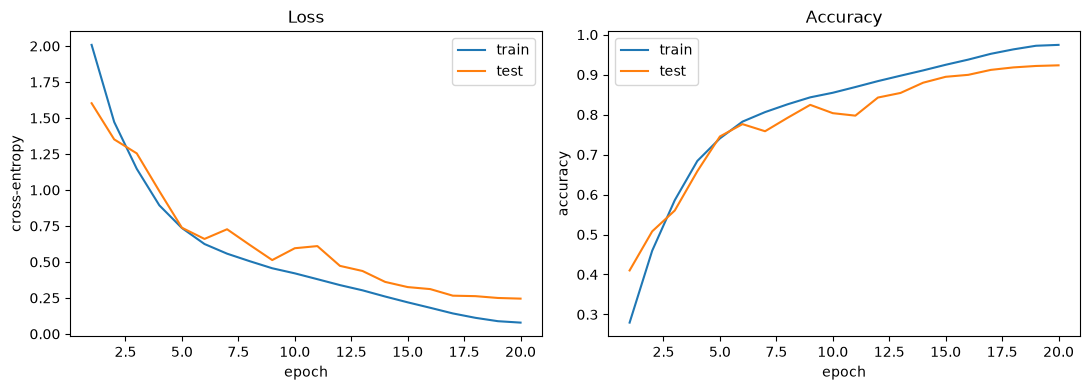

In [11]:
epochs_x = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epochs_x, history['train_loss'], label='train')
ax1.plot(epochs_x, history['test_loss'],  label='test')
ax1.set_title('Loss');     ax1.set_xlabel('epoch'); ax1.set_ylabel('cross-entropy'); ax1.legend()

ax2.plot(epochs_x, history['train_acc'], label='train')
ax2.plot(epochs_x, history['test_acc'],  label='test')
ax2.set_title('Accuracy'); ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy'); ax2.legend()

plt.tight_layout()
plt.show()

## 7. Final evaluation and per-class accuracy

We reload the best checkpoint and report overall test accuracy plus a per-class breakdown — a
standard diagnostic that shows *which* classes the model confuses (cats vs. dogs are perennially
the hardest on CIFAR-10).

In [12]:
# Restore the best weights we saved during training.
if best_state is not None:
    model.load_state_dict(best_state)

# Overall accuracy + counts per class.
n_classes = len(CLASSES)
class_correct = [0] * n_classes
class_total   = [0] * n_classes

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        preds = model(images).argmax(1)
        for label, pred in zip(labels, preds):
            class_total[label]   += 1
            class_correct[label] += int(pred == label)

overall = sum(class_correct) / sum(class_total)
print(f'Overall test accuracy: {overall:.2%}\n')
print(f'{"class":<12} accuracy')
print('-' * 24)
for i, name in enumerate(CLASSES):
    print(f'{name:<12} {class_correct[i] / class_total[i]:6.2%}')

Overall test accuracy: 92.33%

class        accuracy
------------------------
airplane     93.90%
automobile   96.50%
bird         89.70%
cat          82.30%
deer         93.50%
dog          87.80%
frog         93.30%
horse        95.10%
ship         95.90%
truck        95.30%


## 8. Save the trained model

The standard way to persist a model is to save its **`state_dict`** (just the learned tensors, not
the Python class). To use it later you rebuild the same architecture and call `load_state_dict`.

In [13]:
save_path = 'cifar10_resnet18.pt'
torch.save(model.state_dict(), save_path)
print(f'Saved weights to {os.path.abspath(save_path)}')

# To load later:
#   model = make_cifar_resnet18(num_classes=10)
#   model.load_state_dict(torch.load('cifar10_resnet18.pt', map_location=DEVICE))
#   model.eval()

print('\nDone. This same transforms -> dataset -> loader -> model -> loss/optim -> epoch-loop')
print('skeleton is the standard PyTorch training recipe; swap the dataset and model to reuse it.')

Saved weights to o:\Sources\GitHub\TrueRottweiler\WashingtonCsed504\src\a1-cv\cifar10_resnet18.pt

Done. This same transforms -> dataset -> loader -> model -> loss/optim -> epoch-loop
skeleton is the standard PyTorch training recipe; swap the dataset and model to reuse it.
